#### Oliver Mann
## Computablility & Complexity

In [11]:
import numpy as np
import matplotlib.pylab as plt

### Q 1A

> Design a Turing machine that inputs a sequence of $n$ 1s, followed by a 0, followed by a sequence of $m$ 1s and outputs a single sequence of $n + m$ 1s

Inputs a sequence on $n$ 1s, followed by a 0, followed by a sequence of $m$ 1s and and outputs a single sequence of $n+m$ 1s.

($q_i$, 1, R, $q_j$)

scan along 1s until separator <br>
(q_1, 1, R, q_1)<br>

move seapatator along by rewritng it as a 1 and writing the cell to the right as 0<br>
(q_1, 0, 1, q_2)<br>
(q_2, 1, R, q_3)<br>
(q_3, 1, 0, q_1)<br>

detect consecutive 0 (reached end of $n + m$) and correct the aditional written 1<br>
(q_3, 0, L, q_4)<br>
(q_4, 1, 0, q_5)<br>
(q_5, 0, L, q_6)<br>

move back to original position, until the TM reaches a 0, and halt<br>
(q_6, 1, L, q_6)<br>
(q_6, 0, R, q_7)<br>
(q_7, 1, halt, q_7)<br>


In [ ]:

def left(tape,location):
    '''
    moves left along the tape
    extends lists with 0 if TM reaches the left end of the list
    '''
    if location==0:
        tape.insert(0, 0)
    else:
        location=location-1
    return [tape,location]


def right(tape,location):
    '''
    moves right along the tape
    extends lists with 0 if TM reaches the right end of the list
    '''
    l=len(tape)
    if location==l-1:
        tape.insert(l, 0)
        location=l
    else:
        location=location+1
    return [tape,location]

# the instructions of the Turing machine are represented
# by if and elif statement    

def tmrule(location,state,tape):
    if state==1 and tape[location]==1:
        m=right(tape, location)
        location=m[1]
        tape=m[0]
        state=1
    elif state==1 and tape[location]==0:
        tape[location]=1
        state=2
    elif state==2 and tape[location]==1:
        m=right(tape, location)
        location=m[1]
        tape=m[0]
        state=3
    elif state==3 and tape[location] == 1:
        tape[location]=0
        state=1
    elif state==3 and tape[location] == 0:
        m=left(tape, location)
        location=m[1]
        tape=m[0]
        state=4
    elif state==4 and tape[location] == 1:
        tape[location]=0
        state=5
    elif state==5 and tape[location] == 0:
        m=left(tape, location)
        location=m[1]
        tape=m[0]
        state=6
    elif state==6 and tape[location] == 1:
        m=left(tape, location)
        location=m[1]
        tape=m[0]
        state=6
    elif state==6 and tape[location] == 0:
        m=right(tape, location)
        location=m[1]
        tape=m[0]
        state=7
    elif state==7 and tape[location] == 1:
        tape[location]=1
        state=7
    return [location,state,tape]

def runtm(location, state, tape):
    clocation = location
    cstate = state
    ctape = tape
    while cstate!=7:
        print('tape=', ctape, 'location=', clocation, 'state=', cstate)
        x=tmrule(clocation, cstate, ctape)
        clocation=x[0]
        cstate=x[1]
        ctape=x[2]
    print('tape=', ctape, 'location=', clocation, 'state=', cstate)
    return(clocation, cstate, ctape)

tape1 = [1,1,1,1,1,0,1]     # output should contain [1,1,1,1,1,1] with location on the first 1
tape2 = [1,0,1,1,1]         # outåput should contain [1,1,1,1] with location on the first 1

print('TEST CASE 1')
runtm(0,1,tape1)
print('TEST CASE 2')
runtm(0,1,tape2)

#### Q 1C

Theorem: $\log{_2}({n+1})$ is a recursive function for $n\in \mathbb{N}$

let $f(n)=⌈\log{_2}​(n+1)⌉$

$f(0)=\log{_2}((0)+1)$ (base case)

$f(n)=1+f(⌊\frac{n}{2}⌋)$ for $n≥1$ (reccursive step)

Therefore $f(n) = \begin{cases} 0 & \text{if } n = 0 \\ 1 + f\!(\lfloor n/2 \rfloor) & \text{if } n ≥ 1 \end{cases}$



#### Q 1D

> Write a doccumented ```binarysearch``` function. Should use reccursivity to take an `ordered_list` and find a `target`

In [ ]:

ITERATION = 0

def binarysearch(ordered_list, target, lower=0, upper=None):
    '''
    Inputs:     ordered_list (list): a list of integers in ascending order
                target (int): target element within the ordered list
    Ouputs:     position of target element in ordered list (int)
                or 'fail' is target is not present (str)
    '''

    global ITERATION
    ITERATION += 1
    
    if upper == None:
        upper = len(ordered_list) - 1

    # check if list is empty or for error in calculating middle / target not in list
    if upper < lower:
        return 'fail'

    middle = (lower + upper) // 2   # round down to the nearest whole number so indexing always uses an integer 

    # if the middle is target, return middle, 
    # else continue the search in the half of the list with the target in it
    if ordered_list[middle] == target:
        return middle   # target index found 
    elif target < ordered_list[middle]:
        return binarysearch(ordered_list, target, lower, middle-1)
    else:
        return binarysearch(ordered_list, target, middle + 1, upper)


# TESTS
'''
Following tests assert 
'''
list1 = [1, 2, 3, 4, 5, 7, 9, 10, 100]
list2 = [2, 2, 2, 3, 4, 4, 5, 6, 10]
list3 = []
# target in the list
assert binarysearch(list1, 4) == 3
# target not in the list
assert binarysearch(list1, 11) == 'fail'
# first element
assert binarysearch(list1, 1) == 0
# last element
assert binarysearch(list2, 10) == 8
# duplicate values of target in list
assert binarysearch(list2, 4) in [4,5]
# empty list
assert binarysearch(list3, 1) == 'fail'



#### Q 1E

> Show that the worst case time complexity of the binary search algorithm in
Q1d is $O(\log{_2}({n}))$.

For each iteration of binary search, the search interval is halved. In the worst case, this continues until only one element remains. Therefore, the sequence of remaining list lengths is geometric with common ratio $\frac12$.

$A_i = n (\frac{1}{2})^{i}$, where $A_i$ is the list length after $i$ iterations and $n$ is the orderd list length.

In the worst case, after $k$ iterations, the list has length 1: $i = k$ and $A_k = 1$

$1 = n (\frac{1}{2})^{k}$

$\frac{1}{n} = (\frac{1}{2})^{k}$

$n = 2^{k}$

$k = \log{_2}({n})$

Therefore, the worst case time complexity of the binary search algorithm is $O(\log{_2}({n}))$


#### Q 1E

> Show how the average number of iterations taken by `binary_search` changes with list length

In [ ]:

runs = 1000
lengths = 10

it_runs = [2**x for x in range(lengths)]
iterations = []

for i in range(lengths):
    ITERATION = 0
    for j in range(runs):
        it_list = range(2**i)
        it_target = np.random.choice(it_list)
        binarysearch(it_list, it_target)
    iterations.append(ITERATION/runs)

print(it_runs)
print(iterations)

/var/folders/vg/f3bvtrgx4vv7kwd38mnwcpxc0000gn/T/ipykernel_36610/2942440848.py:2: RuntimeWarning: divide by zero encountered in log2
  plt.plot(x, np.log2(x), linestyle='dashed', color='b', label='log_2(n)')
/var/folders/vg/f3bvtrgx4vv7kwd38mnwcpxc0000gn/T/ipykernel_36610/2942440848.py:9: RuntimeWarning: divide by zero encountered in log2
  plt.plot(x, n_fit[0] * np.log2(x) + n_fit[1], color='c', label='n fitted')


array([0.7934, 0.5302])

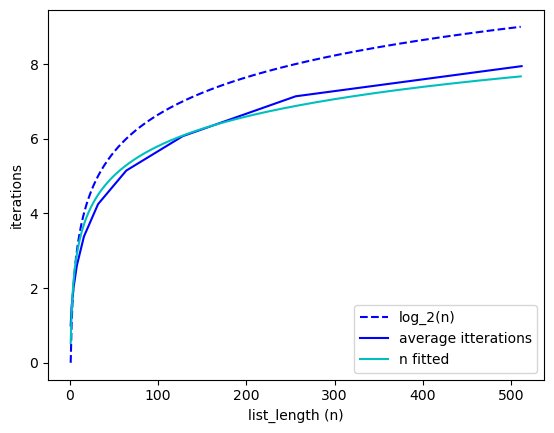

In [ ]:
x = range(2**(lengths-1))
plt.plot(x, np.log2(x), linestyle='dashed', color='b', label='log_2(n)')
plt.plot(it_runs, iterations, color='b', label='average itterations')
plt.xlabel('list_length (n)')
plt.ylabel('iterations')

n_fit = np.polyfit(np.log2(it_runs), iterations, 1)

plt.plot(x, n_fit[0] * np.log2(x) + n_fit[1], color='c', label='n fitted')
plt.legend()

n_fit

> Evaluate whether the average time complexity of `binary_search` is $O(\log_2 n)$

The results show that the average number of iterations increases logarithmically with list length. The close fit between the average itteration data and the function fitted to $\log_2(n) + b$ supports the hypothesis that the average time complexity of binary search is $O(\log_2 n)$